In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("student dataset.csv")
print(df.head())

  College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0030  107             6.61  6.28                     8   
1    CLG0061   97             5.52  5.37                     8   
2    CLG0036  109             5.36  5.83                     9   
3    CLG0055  122             5.47  5.75                     6   
4    CLG0004   96             7.91  7.69                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8                    10   

   Projects_Completed Placement  
0                   4        No  
1                   0        No  
2                   1        No  
3                   1       

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [4]:
df.isnull().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

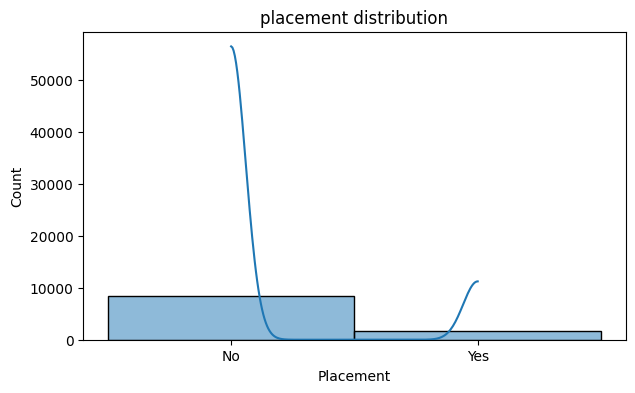

In [5]:

plt.figure(figsize=(7,4))
sns.histplot(df["Placement"], kde=True)
plt.title("placement distribution")
plt.show()

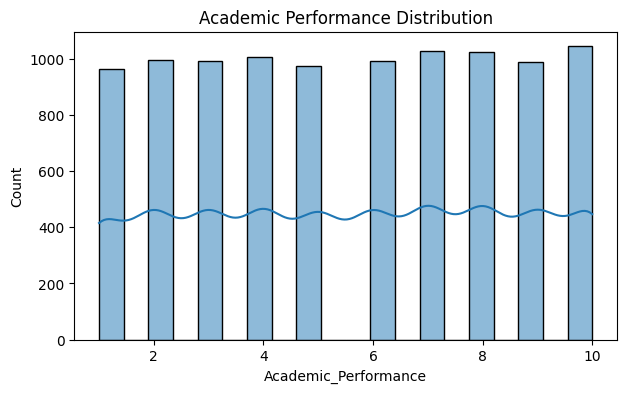

In [6]:
plt.figure(figsize=(7,4))
sns.histplot(df["Academic_Performance"], kde=True)
plt.title("Academic Performance Distribution")
plt.show()


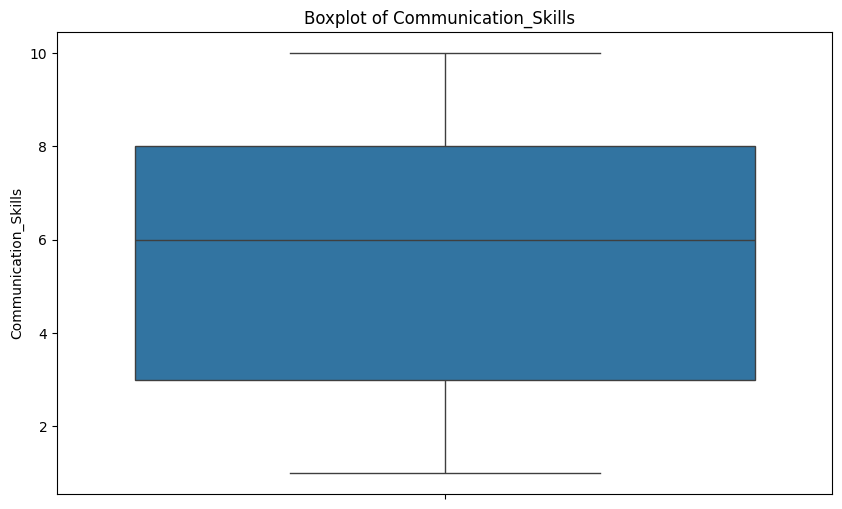

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Communication_Skills'])
plt.title("Boxplot of Communication_Skills  ")
plt.show()


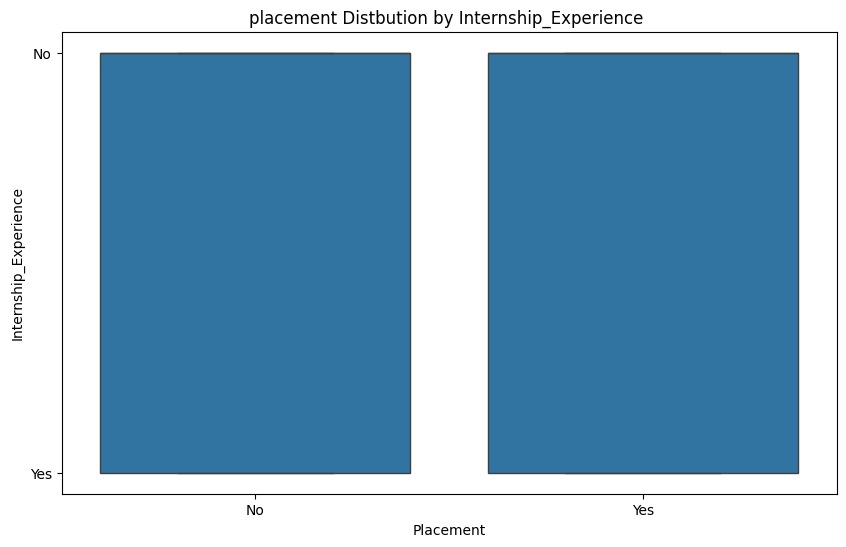

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Placement', y='Internship_Experience', data=df)
plt.title("placement Distbution by Internship_Experience ")
plt.show()

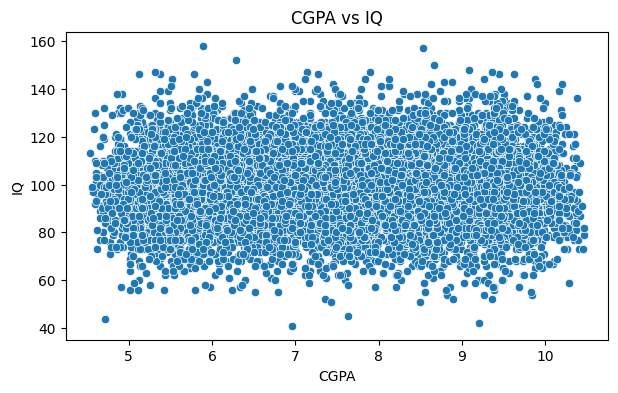

In [9]:
plt.figure(figsize=(7,4))
sns.scatterplot(x='CGPA', y='IQ', data=df)
plt.title("CGPA vs IQ")
plt.show()

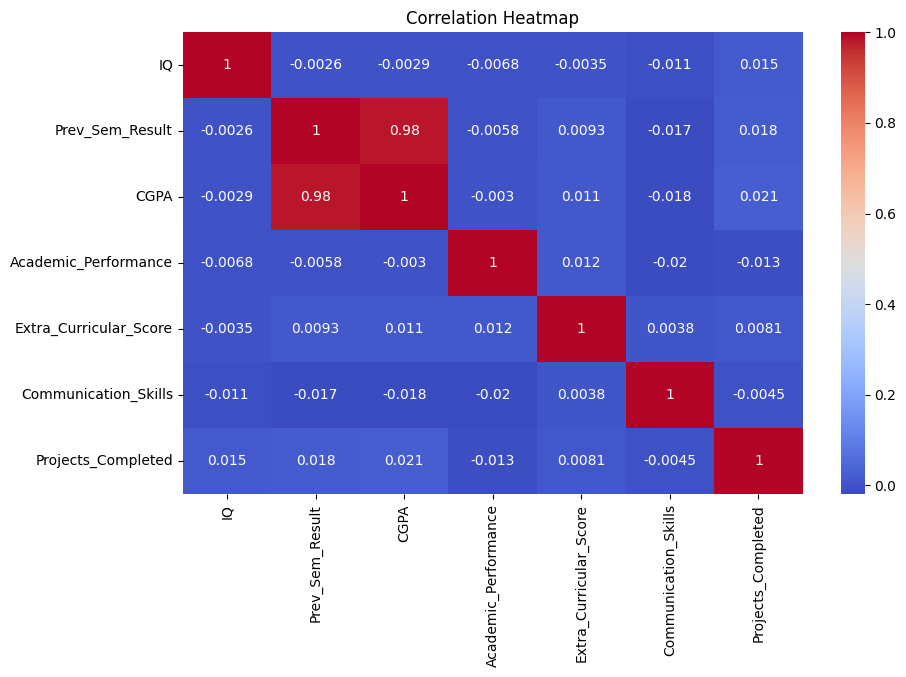

In [10]:

numeric=df.select_dtypes(include='number')
plt.figure(figsize=(10,6))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


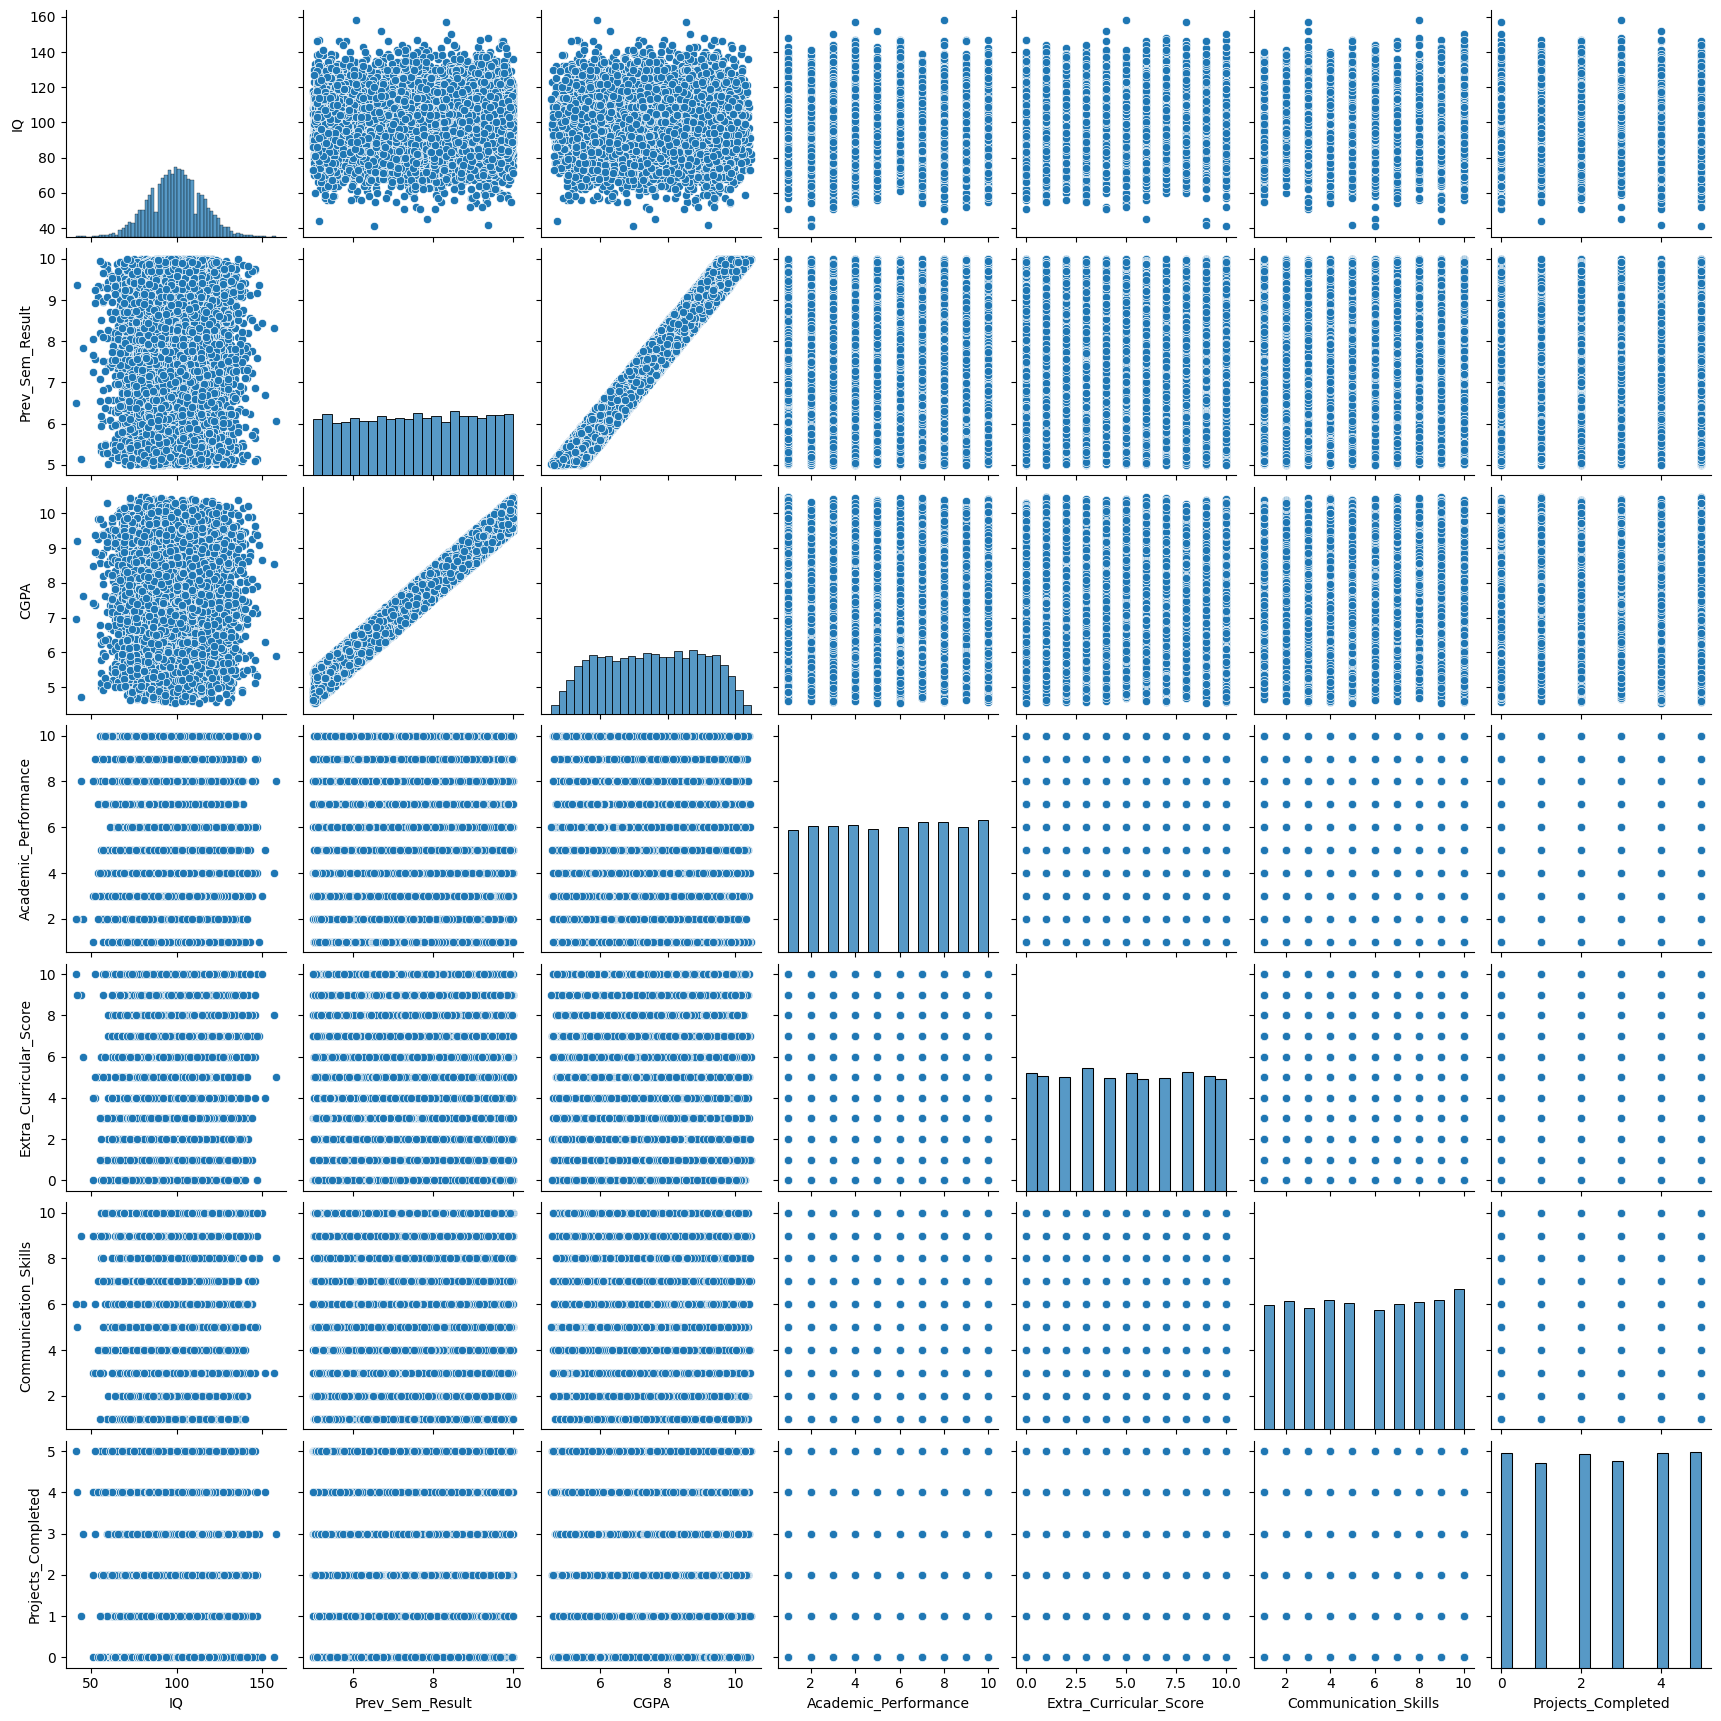

In [12]:
sns.pairplot(df[['IQ','Prev_Sem_Result','CGPA','Academic_Performance','Extra_Curricular_Score','Communication_Skills','Projects_Completed']])

plt.show()

In [13]:
encode=['Internship_Experience','Placement']

In [14]:
le=LabelEncoder()

In [15]:
for col in encode:
    df[col]=le.fit_transform(df[col])

In [16]:
print(df['Internship_Experience'],df['Placement'])

0       0
1       0
2       0
3       1
4       0
       ..
9995    0
9996    0
9997    1
9998    0
9999    0
Name: Internship_Experience, Length: 10000, dtype: int64 0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    0
9997    0
9998    0
9999    0
Name: Placement, Length: 10000, dtype: int64


In [19]:
X=df.drop("Placement",axis=1)##Feature
Y=df["Placement"]##target

In [20]:
feature_train,feature_test,target_train,target_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [21]:
model=DecisionTreeClassifier(criterion="gini",random_state=42)
model.fit(X,Y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
Y_pred=model.predict(feature_test)

In [23]:
print("Accuracy:",accuracy_score(target_test,Y_pred)*100)

Accuracy: 100.0


<function matplotlib.pyplot.show(close=None, block=None)>

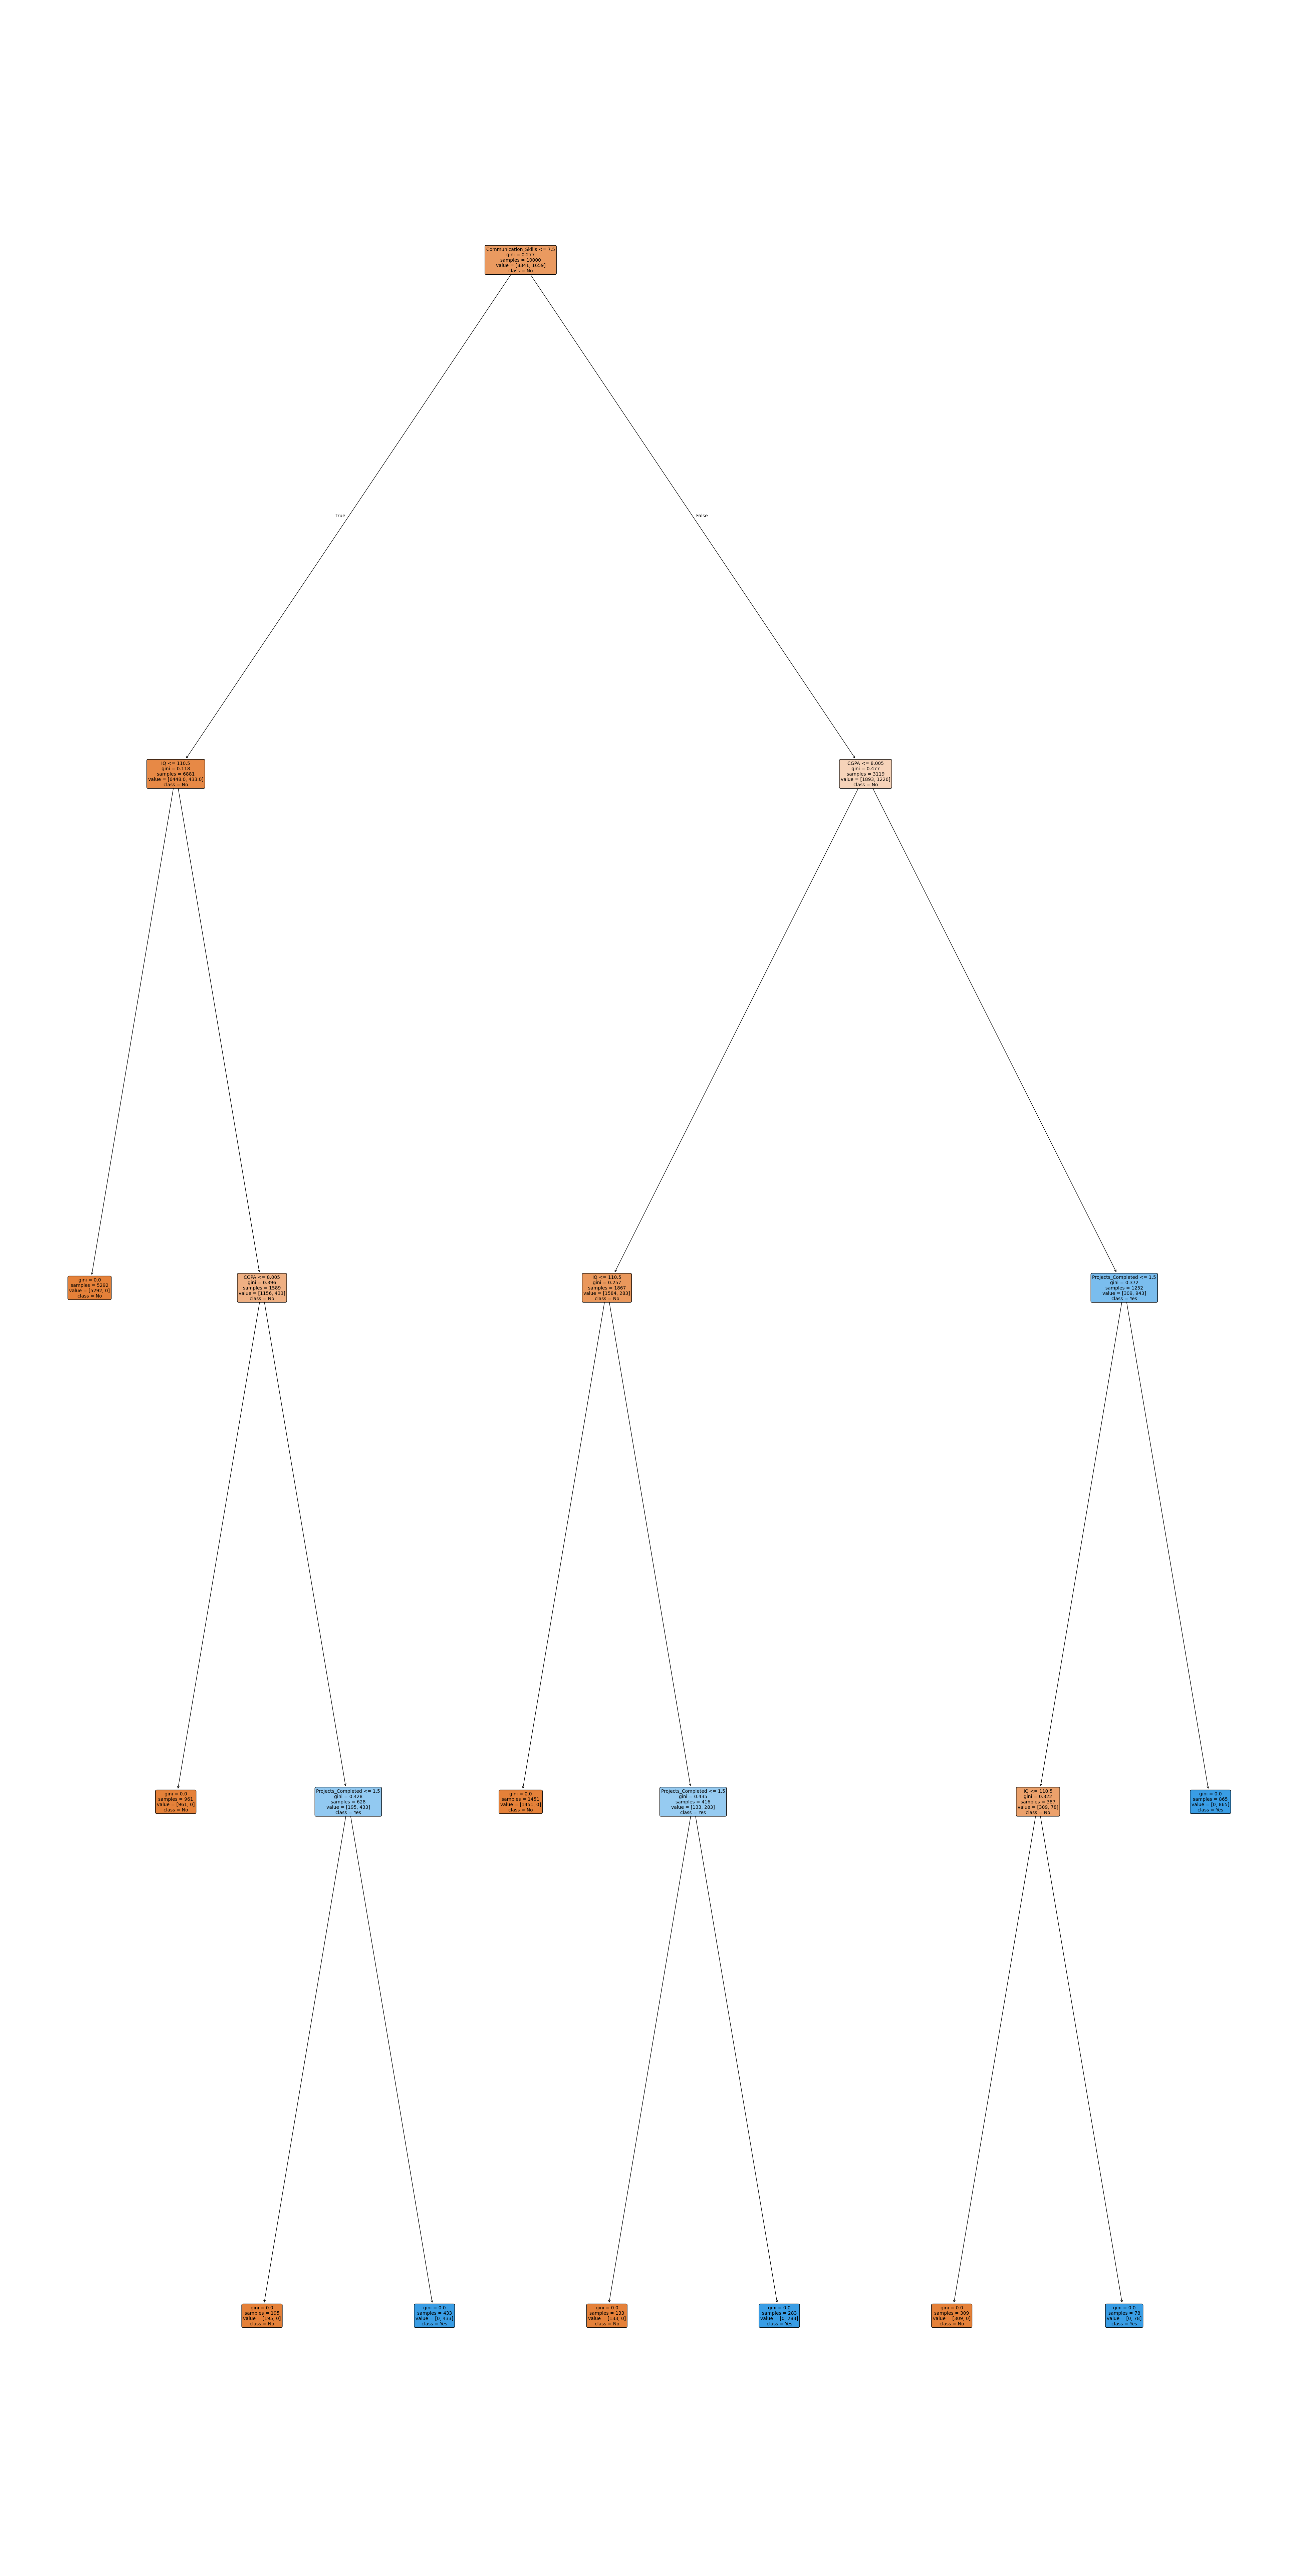

In [24]:
plt.figure(figsize=(50,100))
plot_tree(model,feature_names=X.columns,class_names=["No","Yes"],filled=True,impurity=True,rounded=True,fontsize=10)
plt.show
